In [75]:
from dataclasses import dataclass
from heapq import heappop, heappush
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import warnings

import matplotlib.pyplot as plt
import napari
import numpy as np
import pandas as pd
from liffile import LifFile
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter
from skimage import exposure
from skimage.draw import line as sk_line
from skimage.filters import median, sato, threshold_li, threshold_minimum, threshold_otsu, threshold_triangle
from skimage.measure import label
from skimage.morphology import (
    binary_closing,
    binary_dilation,
    binary_erosion,
    binary_opening,
    disk,
    remove_small_holes,
    remove_small_objects,
    skeletonize,
)

warnings.filterwarnings("ignore")


def label_colormap(color, alpha=1.0):
    rgba = np.array(to_rgba(color))
    rgba[3] = alpha
    return {
        0: np.array([0.0, 0.0, 0.0, 0.0]),
        1: rgba,
    }


In [76]:
# -------------------------
# Utilities
# -------------------------

def plot_slice_debug(img, bw, path_mask, title, z, vr):
    fig, ax = plt.subplots(1, 3, figsize=(6, 3))
    ax[0].imshow(img, cmap="gray")
    ax[0].set_title(f"z={z}")

    ax[1].imshow(bw, cmap="gray")
    ax[1].set_title(title)

    ax[2].imshow(img, cmap="gray")
    if path_mask is not None:
        y, x = np.nonzero(path_mask)
        ax[2].scatter(x, y, s=2, c="red")
    ax[2].set_title("path")

    for a in ax:
        a.axis("off")

    plt.suptitle(f"VR={vr:.3f}")
    plt.tight_layout()
    plt.show()


def vertical_brightness_ratio(img: np.ndarray, eps: float = 1e-6) -> float:
    """Abs(log(median(top)/median(bottom))). Used to gate edge vs ridge mode."""
    y = img.shape[0] // 2
    a = float(np.median(img[:y]))
    b = float(np.median(img[y:]))
    return float(abs(np.log((a + eps) / (b + eps))))


def fit_line_fast(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    """Fast least-squares y=a*x+b, avoiding np.polyfit overhead."""
    n = x.size
    if n < 2:
        return 0.0, float(y[0]) if n else 0.0

    x = x.astype(np.float32, copy=False)
    y = y.astype(np.float32, copy=False)

    xm, ym = x.mean(), y.mean()
    dx = x - xm
    denom = float(np.dot(dx, dx))
    if denom == 0.0:
        return 0.0, float(ym)

    a = float(np.dot(dx, y - ym) / denom)
    b = float(ym - a * xm)
    return a, b


def extend_path_to_edges(
    path_mask: np.ndarray,
    k: int = 5,
    max_gap: int = 30,
    edge_tol: int = 0,
) -> np.ndarray:
    """
    Extend a path to x=0 and/or x=W-1 if its endpoints are within max_gap of those edges.
    Uses k extreme points and a linear fit to extrapolate.
    """
    m = path_mask.astype(bool).copy()
    H, W = m.shape
    ys, xs = np.nonzero(m)
    n = xs.size
    if n < 2:
        return m

    x_min, x_max = int(xs.min()), int(xs.max())
    left_gap, right_gap = x_min, (W - 1) - x_max

    if left_gap <= edge_tol and right_gap <= edge_tol:
        return m
    if left_gap > max_gap and right_gap > max_gap:
        return m

    kk = min(k, n)

    if left_gap <= max_gap:
        idx = np.argpartition(xs, kk - 1)[:kk]
        a, b = fit_line_fast(xs[idx], ys[idx])
        x0 = x_min
        y0 = int(np.clip(np.rint(a * x0 + b), 0, H - 1))
        y_edge = int(np.clip(np.rint(b), 0, H - 1))  # x=0
        rr, cc = sk_line(y_edge, 0, y0, x0)
        m[rr, cc] = True

    if right_gap <= max_gap:
        idx = np.argpartition(xs, n - kk)[-kk:]
        a, b = fit_line_fast(xs[idx], ys[idx])
        x1 = x_max
        y1 = int(np.clip(np.rint(a * x1 + b), 0, H - 1))
        y_edge = int(np.clip(np.rint(a * (W - 1) + b), 0, H - 1))
        rr, cc = sk_line(y1, x1, y_edge, W - 1)
        m[rr, cc] = True

    return m


def _largest_component(mask: np.ndarray) -> np.ndarray:
    lab = label(mask)
    if lab.max() == 0:
        return mask.astype(bool)
    areas = np.bincount(lab.ravel())
    areas[0] = 0
    keep = int(np.argmax(areas))
    return lab == keep


def _largest_n_components(mask: np.ndarray, n_keep: int = 3) -> np.ndarray:
    lab = label(mask)
    if lab.max() == 0:
        return mask.astype(bool)
    areas = np.bincount(lab.ravel())
    areas[0] = 0
    keep = np.argsort(areas)[-n_keep:]
    return np.isin(lab, keep)


def extract_boundary(
    img: np.ndarray,
    thr_func,
    min_size: int = 100,
    hole_area: int = 500,
    opening_size: int = 3,
) -> Tuple[np.ndarray, np.ndarray]:
    """Threshold + clean + keep largest region + return interface boundary as a 1px mask."""
    bw = img > thr_func(img)
    if min_size > 0:
        bw = remove_small_objects(bw, min_size=min_size)
    if hole_area > 0:
        bw = remove_small_holes(bw, area_threshold=hole_area)
    if opening_size > 0:
        bw = binary_opening(bw, disk(opening_size))

    bw = _largest_component(bw)

    # boundary of region
    path = bw ^ binary_erosion(bw, disk(1))
    path = _largest_component(path)
    return path.astype(bool), bw.astype(bool)


# -------------------------
# Routing on skeleton
# -------------------------

_NEIGH8 = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]


def find_best_left_right_route(
    mask: np.ndarray,
    edge_margin: int = 30,
    step_cost: float = 100.0,
) -> Optional[np.ndarray]:
    """
    Multi-source Dijkstra from any left-edge point to any right-edge point.
    Prefers paths on mask; allows small off-mask moves via penalty.
    """
    H, W = mask.shape
    left = np.argwhere(mask[:, :edge_margin])
    right = np.argwhere(mask[:, W - edge_margin :])

    if left.size == 0 or right.size == 0:
        m2 = binary_dilation(mask, disk(2))
        left = np.argwhere(m2[:, :edge_margin])
        right = np.argwhere(m2[:, W - edge_margin :])
        if left.size == 0 or right.size == 0:
            return None
        mask = m2

    right_set = {(int(y), int(W - edge_margin + x)) for y, x in right}

    off_penalty = step_cost * 0.2
    cost = np.where(mask, step_cost, step_cost + off_penalty).astype(np.float32, copy=False)

    visited = np.zeros((H, W), dtype=bool)
    prev: Dict[Tuple[int, int], Optional[Tuple[int, int]]] = {}
    pq: List[Tuple[float, Tuple[int, int]]] = []

    for y, x in left:
        p = (int(y), int(x))
        heappush(pq, (0.0, p))
        prev[p] = None

    end: Optional[Tuple[int, int]] = None

    while pq:
        c, (y, x) = heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = True
        if (y, x) in right_set:
            end = (y, x)
            break

        for dy, dx in _NEIGH8:
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W and not visited[ny, nx]:
                nc = c + float(cost[ny, nx])
                heappush(pq, (nc, (ny, nx)))
                prev.setdefault((ny, nx), (y, x))

    if end is None:
        return None

    out = np.zeros((H, W), dtype=bool)
    cur: Optional[Tuple[int, int]] = end
    while cur is not None:
        out[cur] = True
        cur = prev[cur]
    return out


# -------------------------
# Per-slice line extraction
# -------------------------

@dataclass(frozen=True)
class RidgeParams:
    ratio_cutoff: float = 0.75
    med_disk: int = 7

    # edge mode fallbacks
    edge_extend_gap: int = 30

    # ridge mode settings
    sato_sigmas: Tuple[float, ...] = (2, 3, 4, 5, 6, 7, 8)
    ridge_close_disk: int = 9
    ridge_min_size: int = 600
    ridge_keep_components: int = 3
    ridge_extend_gap: int = 50
    edge_margin: int = 30
    step_cost: float = 100.0


def _edge_mode_boundary(img_med: np.ndarray, params: RidgeParams, img_shape: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    """Edge-mode boundary extraction with robustness fallbacks."""
    path, bw = extract_boundary(img_med, threshold_li)

    H, W = img_shape
    if path.sum() > 1.5 * W:
        print("path too long")
        path, bw = extract_boundary(img_med, threshold_minimum, min_size=0, hole_area=0, opening_size=0)
        if path.sum() > 1.5 * W:
            print("still too long")
            from scipy.ndimage import binary_fill_holes

            holes = binary_fill_holes(bw) & ~bw
            holes_grown = binary_dilation(holes, disk(20))
            bw_big_holes = bw & ~holes_grown

            path = bw_big_holes ^ binary_erosion(bw_big_holes, disk(20))
            path = _largest_component(path).astype(bool)

    elif path[0, :].any() or path[-1, :].any():
        g = exposure.adjust_gamma(img_med, gamma=0.2)
        path, bw = extract_boundary(g, threshold_triangle, min_size=0, hole_area=0, opening_size=10)

    path = extend_path_to_edges(path, k=5, max_gap=params.edge_extend_gap)
    return path, bw


def _ridge_mode_boundary(img_med: np.ndarray, params: RidgeParams) -> Tuple[Optional[np.ndarray], np.ndarray]:
    """Ridge-mode boundary extraction via Sato + skeleton routing."""
    resp = sato(img_med, sigmas=params.sato_sigmas, black_ridges=True)
    resp = exposure.rescale_intensity(resp)
    bw = resp > threshold_otsu(resp)
    bw = binary_closing(bw, footprint=disk(params.ridge_close_disk))
    bw = remove_small_objects(bw, min_size=params.ridge_min_size)

    skel = skeletonize(bw)
    skel_main = _largest_n_components(skel, n_keep=params.ridge_keep_components)

    path = find_best_left_right_route(skel_main, edge_margin=params.edge_margin, step_cost=params.step_cost)
    if path is None:
        path = find_best_left_right_route(skel, edge_margin=params.edge_margin, step_cost=params.step_cost)

    if path is not None:
        path = extend_path_to_edges(path, k=5, max_gap=params.ridge_extend_gap)

    return path, bw


def find_ridge_through_plane(
    img: np.ndarray,
    params: RidgeParams = RidgeParams(),
    plot: bool = False,
    z: Optional[int] = None,
) -> Tuple[Optional[np.ndarray], str, float]:
    """
    Returns (path_mask, mode, brightness_ratio).
    mode in {"no_image","edge","ridge","fail"}.
    """
    vr = vertical_brightness_ratio(img)
    if vr == 0.0:
        return None, "no_image", vr

    try:
        img_med = median(img, disk(params.med_disk))
        mode = "edge" if vr > params.ratio_cutoff else "ridge"

        if mode == "edge":
            path, bw = _edge_mode_boundary(img_med, params, img.shape)
        else:
            path, bw = _ridge_mode_boundary(img_med, params)

        if plot:
            plot_slice_debug(img, bw, path, mode, z, vr)
        return path, mode, vr

    except Exception:
        return None, "fail", vr


# -------------------------
# Profile + z collection
# -------------------------

def pathmask_to_profile_y(pm: np.ndarray) -> Optional[np.ndarray]:
    """Convert a sparse 1px-ish path mask into a dense y(x) profile of length W."""
    H, W = pm.shape
    y, x = np.nonzero(pm)
    if y.size < 2:
        return None
    order = np.argsort(x)
    x = x[order].astype(np.float32)
    y = y[order].astype(np.float32)
    x_u, idx = np.unique(x, return_index=True)
    y_u = y[idx]
    if x_u.size < 2:
        return None
    return np.interp(np.arange(W, dtype=np.float32), x_u, y_u, left=y_u[0], right=y_u[-1]).astype(np.float32)


def collect_lines_over_z(
    vol_zyx: np.ndarray,
    params: RidgeParams = RidgeParams(),
    discard_top_bottom: bool = True,
    plot: bool = False,
) -> Tuple[Dict[int, np.ndarray], Dict[int, np.ndarray], List[int]]:
    """
    Returns:
      lines[z]     -> bool (H,W)
      profiles[z]  -> float32 (W,)
      found_zs     -> sorted list of z where a line exists
    """
    Z, H, W = vol_zyx.shape
    lines: Dict[int, np.ndarray] = {}
    profiles: Dict[int, np.ndarray] = {}
    found: List[int] = []

    for z in range(Z):
        pm, mode, vr = find_ridge_through_plane(
            vol_zyx[z],
            params=params,
            plot=plot,
            z=z,
        )
        if pm is None or pm.sum() == 0:
            continue
        pm = pm.astype(bool)
        if discard_top_bottom and (pm[0, :].any() or pm[-1, :].any()):
            continue
        yx = pathmask_to_profile_y(pm)
        if yx is None:
            continue
        lines[z] = pm
        profiles[z] = yx
        found.append(z)

    return lines, profiles, sorted(found)


# -------------------------
# Keep consistent z-band
# -------------------------

def keep_similar_high_z(
    lines: Dict[int, np.ndarray],
    profiles: Dict[int, np.ndarray],
    found_zs: List[int],
    *,
    missing_run: int = 3,
    diff_thresh_px: Optional[float] = None,
    core_frac: float = 0.6,
    core_min: int = 5,
    min_keep: int = 3,
    consec_bad: int = 2,
    exclude_top_bottom: bool = True,
) -> Tuple[List[int], Dict[int, np.ndarray]]:
    """
    Keep the main contiguous z-band (trims weird ends), with:
      - low-z pre-cut before first missing-run
      - optional exclusion of paths touching top/bottom rows
    """
    zs = sorted([z for z in found_zs if z in lines and z in profiles])
    if not zs:
        return [], {}

    if exclude_top_bottom:
        zs = [z for z in zs if not (lines[z][0, :].any() or lines[z][-1, :].any())]
        if not zs:
            return [], {}

    if len(zs) == 1:
        z0 = zs[0]
        return [z0], {z0: lines[z0]}

    # pre-cut low-z before first missing run (based on remaining zs)
    cut_z = None
    for a, b in zip(zs[:-1], zs[1:]):
        if (b - a - 1) >= missing_run:
            cut_z = a + missing_run
            break
    if cut_z is not None:
        zs = [z for z in zs if z > cut_z]
    if not zs:
        return [], {}

    n = len(zs)
    if n == 1:
        z0 = zs[0]
        return [z0], {z0: lines[z0]}

    core_n = min(n, max(core_min, int(np.ceil(core_frac * n))))
    start = (n - core_n) // 2
    core = zs[start : start + core_n]
    consensus = np.median(np.stack([profiles[z] for z in core], axis=0), axis=0)

    diffs = np.array([np.median(np.abs(profiles[z] - consensus)) for z in zs], dtype=np.float32)

    if diff_thresh_px is None:
        core_diffs = np.array([np.median(np.abs(profiles[z] - consensus)) for z in core], dtype=np.float32)
        med = float(np.median(core_diffs))
        mad = float(np.median(np.abs(core_diffs - med))) + 1e-9
        thr = med + 3.0 * 1.4826 * mad
        print("diff threshold pixel", thr)
    else:
        thr = float(diff_thresh_px)

    good = diffs <= thr

    best = None  # (score, i0, i1)
    i = 0
    while i < n:
        if not good[i]:
            i += 1
            continue

        i0, bad_run, j = i, 0, i
        while j < n:
            if good[j]:
                bad_run = 0
            else:
                bad_run += 1
                if bad_run >= consec_bad:
                    break
            j += 1

        i1 = j
        score = (int(good[i0:i1].sum()), i1 - i0)
        if best is None or score > best[0]:
            best = (score, i0, i1)
        i = i1

    if best is None:
        return [], {}

    _, i0, i1 = best
    kept = [z for z, g in zip(zs[i0:i1], good[i0:i1]) if bool(g)]

    if len(kept) < min_keep:
        kept = [zs[int(np.argmin(diffs))]]

    return kept, {z: lines[z] for z in kept}


# -------------------------
# Surface smoothing + segmentation
# -------------------------

def smooth_surface_yzx(
    profiles: Dict[int, np.ndarray],
    kept_zs: List[int],
    Z: int,
    W: int,
    *,
    sigma_z: float = 1.0,
    sigma_x: float = 2.0,
) -> np.ndarray:
    """Build y[z,x] from kept_zs, interpolate along z per x, then smooth in (z,x)."""
    ysurf = np.full((Z, W), np.nan, dtype=np.float32)
    for z in kept_zs:
        ysurf[z] = profiles[z].astype(np.float32, copy=False)

    zz = np.arange(Z, dtype=np.float32)
    for x in range(W):
        col = ysurf[:, x]
        ok = ~np.isnan(col)
        if ok.sum() >= 2:
            ysurf[:, x] = np.interp(zz, zz[ok], col[ok]).astype(np.float32)
        elif ok.sum() == 1:
            ysurf[:, x] = float(col[ok][0])

    return gaussian_filter(ysurf, sigma=(sigma_z, sigma_x), mode="nearest")


def fill_missing_profiles(profiles: dict[int, np.ndarray], Z: int) -> np.ndarray:
    """
    profiles[z] is (W,) y(x) for that z.
    Returns y_full with shape (Z, W), filled for all z by linear interpolation in z.
    """
    zs = np.array(sorted(profiles.keys()), dtype=int)
    if zs.size == 0:
        raise ValueError("No profiles provided")

    W = int(profiles[zs[0]].shape[0])
    y_full = np.full((Z, W), np.nan, dtype=np.float32)

    for z in zs:
        y_full[z] = profiles[z].astype(np.float32, copy=False)

    zz = np.arange(Z, dtype=np.float32)
    for x in range(W):
        col = y_full[:, x]
        ok = ~np.isnan(col)
        if ok.sum() >= 2:
            col[~ok] = np.interp(zz[~ok], zz[ok], col[ok])
            y_full[:, x] = col
        elif ok.sum() == 1:
            y_full[:, x] = col[ok][0]  # constant fill if only one slice exists

    return y_full


def profiles_to_path_masks(y_full: np.ndarray, H: int) -> np.ndarray:
    """
    y_full is (Z,W) of y(x) values.
    Returns path_vol (Z,H,W) boolean with 1-pixel line in each z.
    """
    Z, W = y_full.shape
    path_vol = np.zeros((Z, H, W), dtype=bool)
    xs = np.arange(W)
    for z in range(Z):
        yy = np.clip(np.rint(y_full[z]).astype(int), 0, H - 1)
        path_vol[z, yy, xs] = True
    return path_vol


def segment_from_smoothed_surface(
    vol_shape_zyx: Tuple[int, int, int],
    kept_zs: List[int],
    profiles: Dict[int, np.ndarray],
    *,
    side: str = "below",
    sigma_z: float = 1.0,
    sigma_x: float = 2.0,
    fill_within_kept_band: bool = True,
) -> Tuple[np.ndarray, np.ndarray, Dict[int, int], int, int, np.ndarray, List[int]]:
    """
    Segment volume using a smoothed boundary surface y(z,x).

    If fill_within_kept_band=True:
      - build a contiguous band from min(kept_zs) to max(kept_zs)
      - segment EVERY z in that band (including planes missing from profiles/lines)

    Returns:
      (region, other, area_by_z, vol_region, vol_other, y_smooth_zx, used_zs)
    """
    Z, H, W = vol_shape_zyx
    if not kept_zs:
        raise ValueError("kept_zs is empty")

    y_smooth = smooth_surface_yzx(profiles, kept_zs, Z, W, sigma_z=sigma_z, sigma_x=sigma_x)

    if fill_within_kept_band:
        z0, z1 = int(min(kept_zs)), int(max(kept_zs))
        used_zs = list(range(z0, z1 + 1))
    else:
        used_zs = list(map(int, kept_zs))

    region = np.zeros((Z, H, W), dtype=bool)
    other = np.zeros((Z, H, W), dtype=bool)
    area_by_z: Dict[int, int] = {}

    Y = np.arange(H)[:, None]
    for z in used_zs:
        yy = np.clip(np.rint(y_smooth[z]).astype(np.int32), 0, H - 1)[None, :]
        below = Y >= yy

        if side == "below":
            region[z] = below
            other[z] = ~below
            area_by_z[z] = int(below.sum())
        elif side == "above":
            region[z] = ~below
            other[z] = below
            area_by_z[z] = int((~below).sum())
        else:
            raise ValueError("side must be 'below' or 'above'")

    return region, other, area_by_z, int(region.sum()), int(other.sum()), y_smooth, used_zs


def step(axis, xa):
    if axis not in xa.coords or xa.coords[axis].size < 2:
        return None
    return float(xa.coords[axis][1] - xa.coords[axis][0])


def segmentation_geometry_failure(
    profiles: Dict[int, np.ndarray],
    kept_zs: List[int],
    y_max: int,
    *,
    frac_bad_thresh: float = 0.5,
    span_frac_thresh: float = 1 / 3,
):
    """
    Check for segmentation failure based on vertical span of interface.

    For each z in kept_zs:
      Δy = |y(x=W-1) - y(x=0)|

    Flags failure if:
      fraction of slices with Δy > span_frac_thresh * y_max
      exceeds frac_bad_thresh.

    Returns
    -------
    failed : bool
    diagnostics : dict
    """
    if not kept_zs:
        return True, {"reason": "no_kept_slices"}

    bad = []
    spans = []

    for z in kept_zs:
        yx = profiles[z]
        y0 = float(yx[0])
        y1 = float(yx[-1])
        dy = abs(y1 - y0)
        spans.append(dy)
        bad.append(dy > span_frac_thresh * y_max)

    bad = np.asarray(bad, dtype=bool)
    spans = np.asarray(spans, dtype=float)

    frac_bad = bad.mean()

    diagnostics = {
        "n_kept": len(kept_zs),
        "n_bad": int(bad.sum()),
        "frac_bad": float(frac_bad),
        "span_thresh_px": span_frac_thresh * y_max,
        "median_span_px": float(np.median(spans)),
        "max_span_px": float(np.max(spans)),
        "spans_px": spans,
    }

    failed = frac_bad > frac_bad_thresh
    return failed, diagnostics


def measure_volumes_and_interface_um(
    maternal: np.ndarray,
    fetal: np.ndarray,
    x_um: float,
    z_um: float,
):
    """
    maternal, fetal: bool (Z,H,W) masks (ideally complements on kept_zs)
    x_um: pixel size in X and Y (µm)
    z_um: spacing in Z (µm)

    Returns: (maternal_um3, fetal_um3, interface_um2)
    """
    vx = float(x_um)
    vy = float(x_um)
    vz = float(z_um)

    voxel_vol = vx * vy * vz

    maternal_um3 = float(maternal.sum()) * voxel_vol
    fetal_um3 = float(fetal.sum()) * voxel_vol

    # Count maternal↔fetal adjacencies across the 3 axes (6-neighbour interface)
    # x-faces have area vy*vz, y-faces vx*vz, z-faces vx*vy
    adj_x = (maternal[:, :, :-1] & fetal[:, :, 1:]) | (fetal[:, :, :-1] & maternal[:, :, 1:])
    adj_y = (maternal[:, :-1, :] & fetal[:, 1:, :]) | (fetal[:, :-1, :] & maternal[:, 1:, :])
    adj_z = (maternal[:-1, :, :] & fetal[1:, :, :]) | (fetal[:-1, :, :] & maternal[1:, :, :])

    interface_um2 = (
        float(adj_x.sum()) * (vy * vz)
        + float(adj_y.sum()) * (vx * vz)
        + float(adj_z.sum()) * (vx * vy)
    )

    return maternal_um3, fetal_um3, interface_um2


def permeability_calculation(
    final_fetal_intensity,
    initial_fetal_intensity,
    initial_maternal_intensity,
    time_separation_s,
    bleaching_coefficient,
    fetal_um3,
    interface_um2,
):
    p_um_per_s = (1 / time_separation_s) * (fetal_um3 / interface_um2) * (
        ((bleaching_coefficient * final_fetal_intensity) - initial_fetal_intensity)
        / ((initial_maternal_intensity) - (initial_fetal_intensity))
    )
    p_cm_per_s = p_um_per_s * 0.0001
    return p_cm_per_s



In [82]:
# -------------------------
# I/O + analysis pipeline (batch)
# -------------------------
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity")
# folder = Path(r"Z:\Marta\Barrier project\Imaging\Stellaris\3D\Drugs")
lif_files = list(folder.glob("**/*.lif"))
print(len(lif_files))
lif_files = [p for p in lif_files if "Day5_Exp6.lif" not in str(p) ]
print(len(lif_files))


11
10


10
path too long
path too long


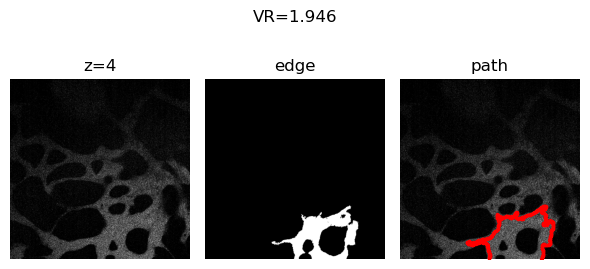

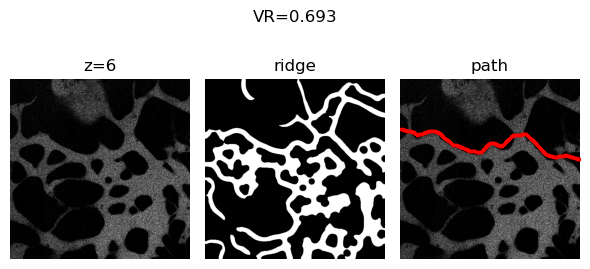

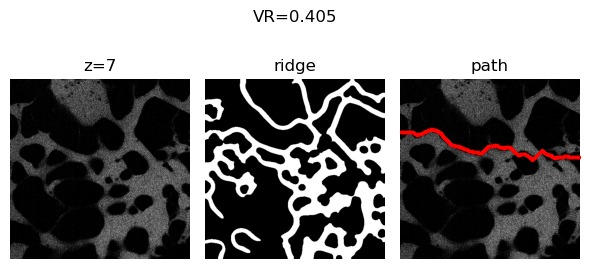

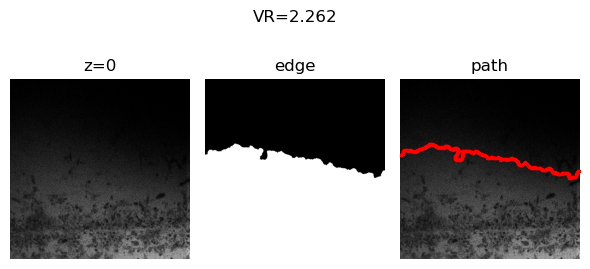

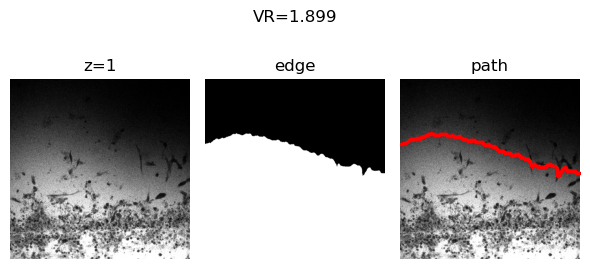

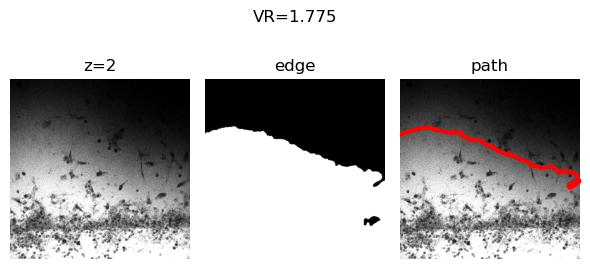

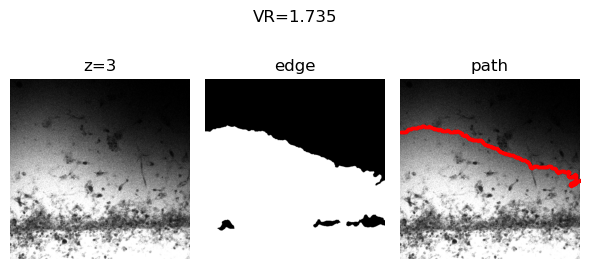

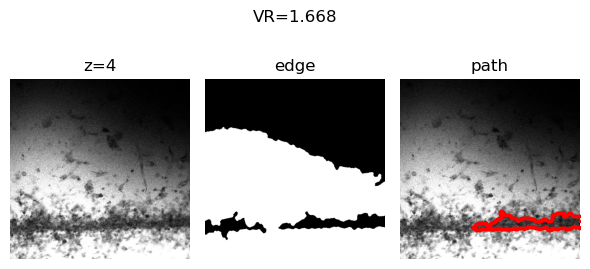

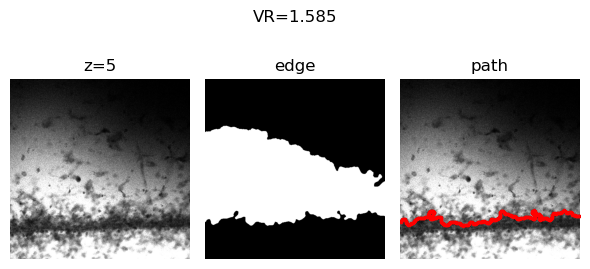

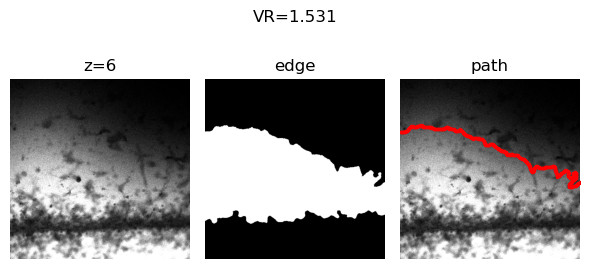

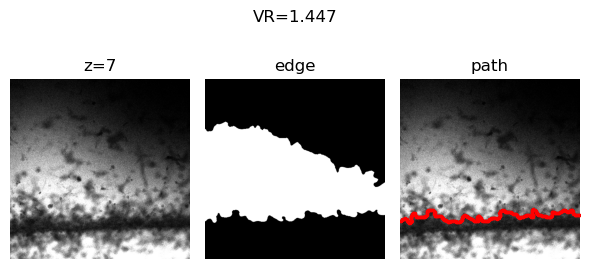

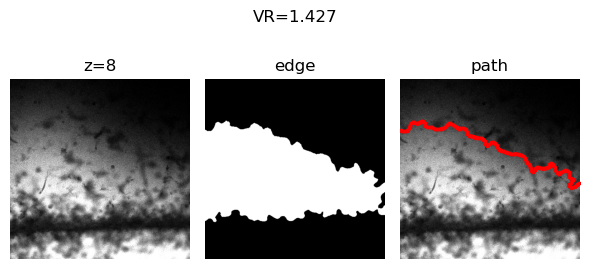

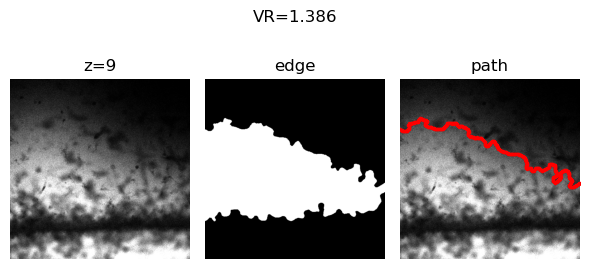

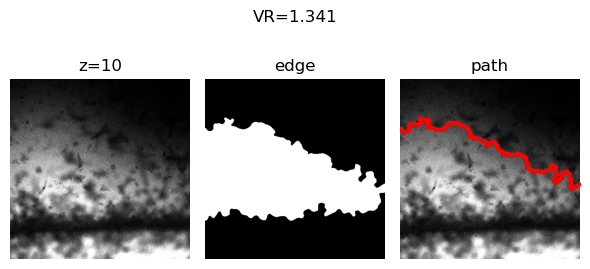

path too long
still too long


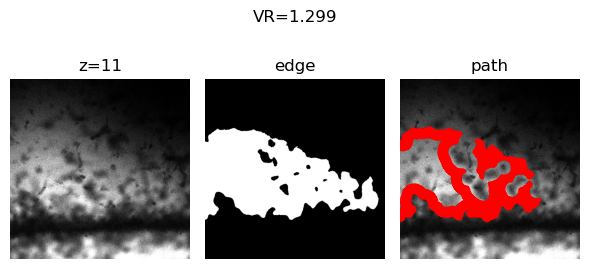

path too long
still too long


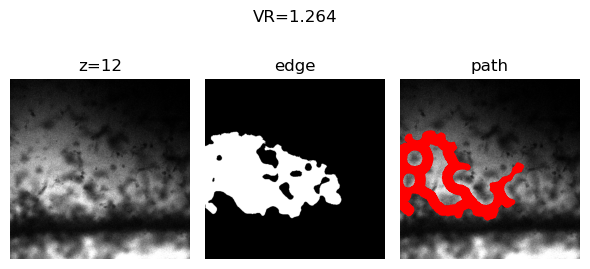

path too long
still too long


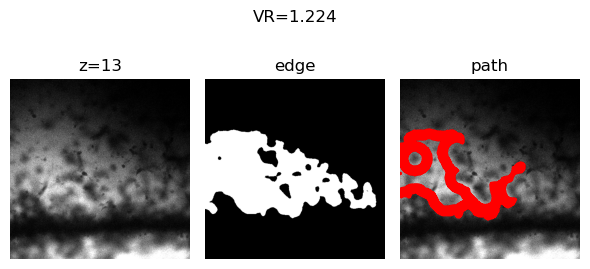

path too long
still too long


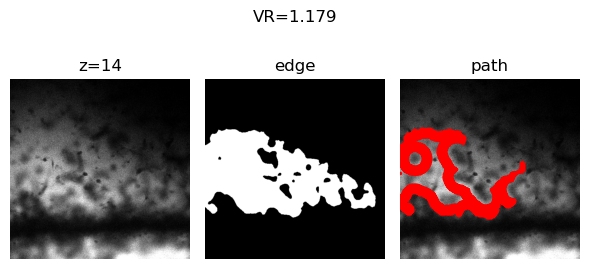

path too long
still too long


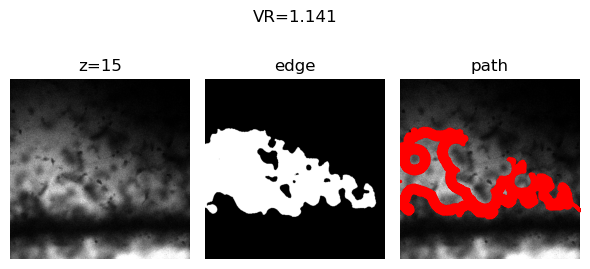

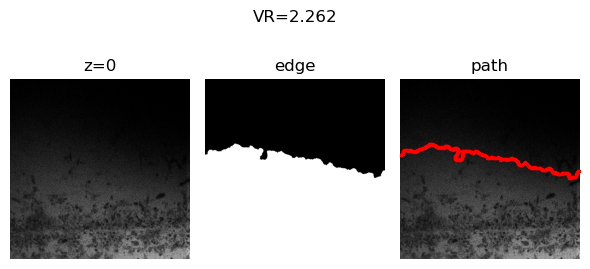

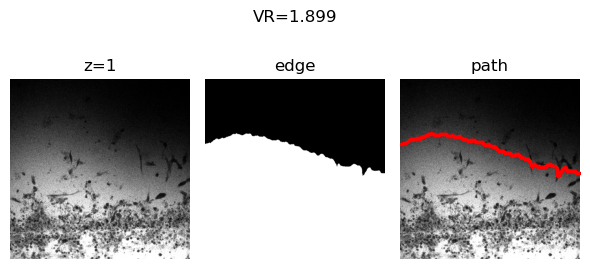

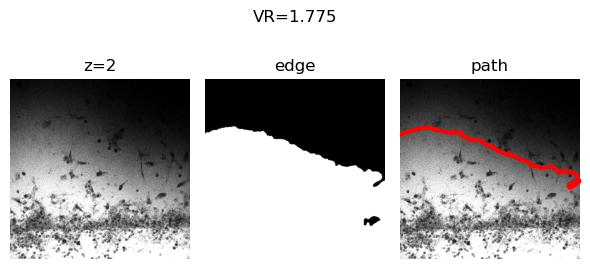

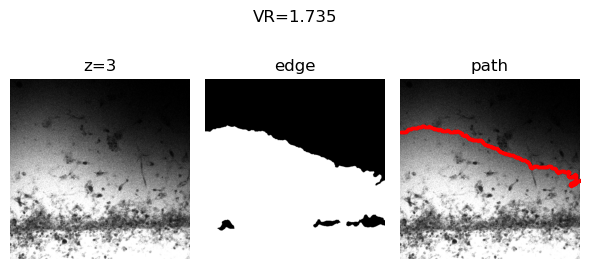

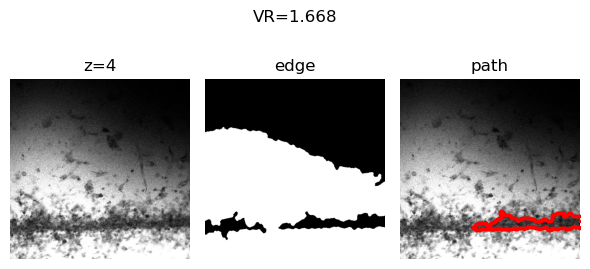

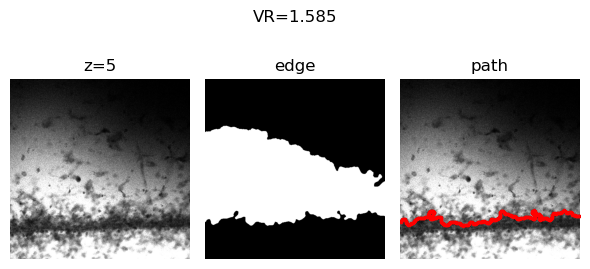

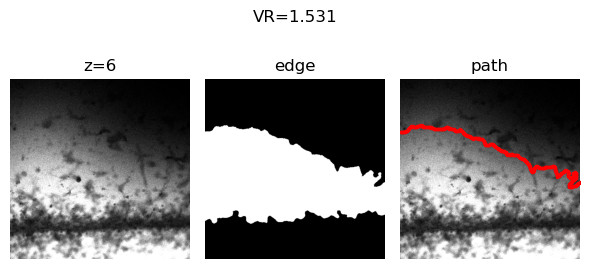

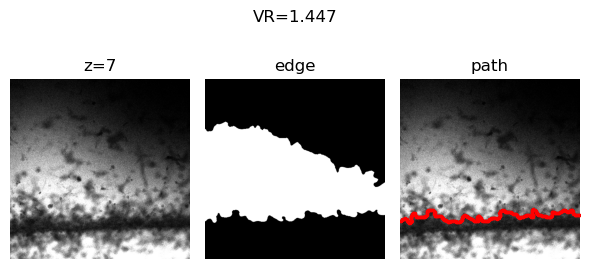

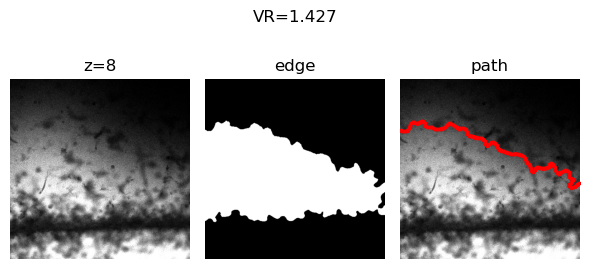

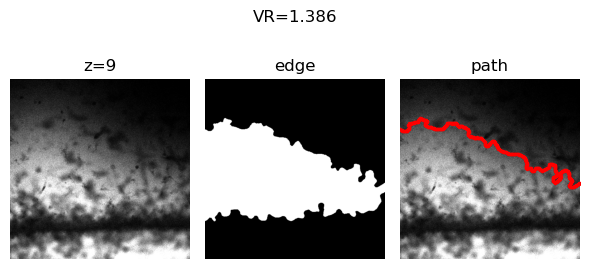

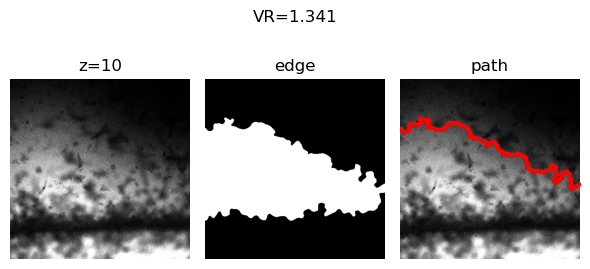

path too long
still too long


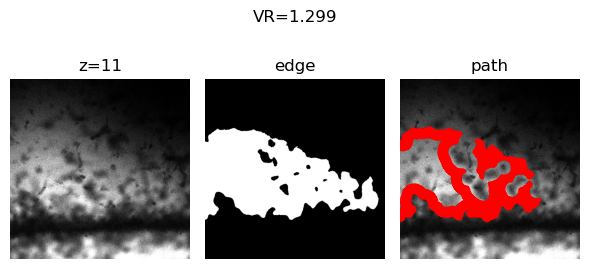

path too long
still too long


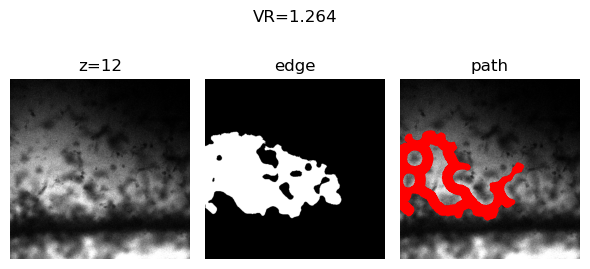

path too long
still too long


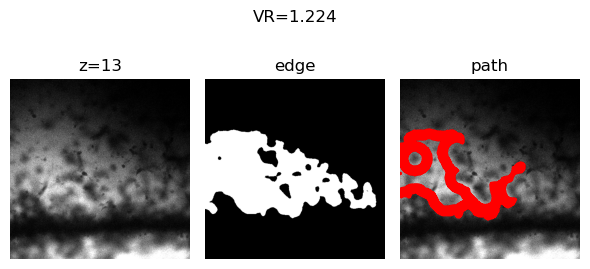

path too long
still too long


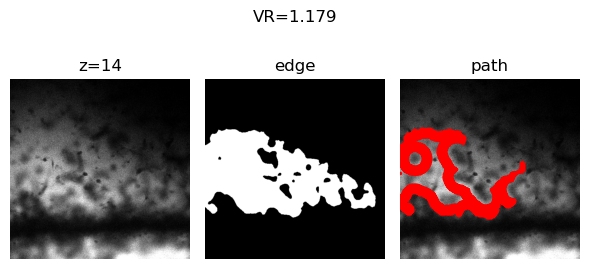

path too long
still too long


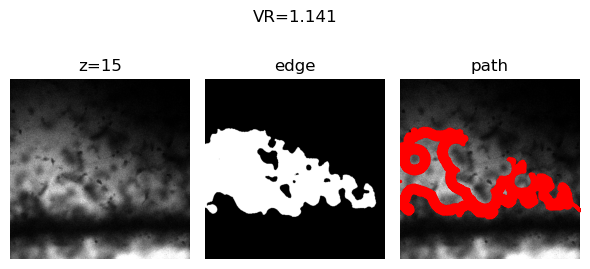

path too long


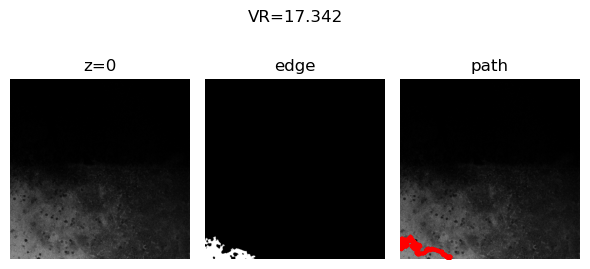

path too long
still too long


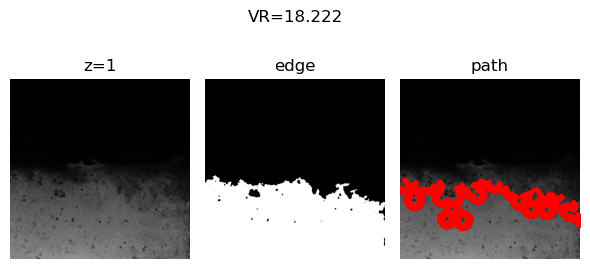

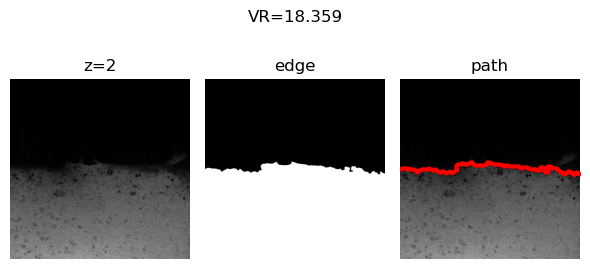

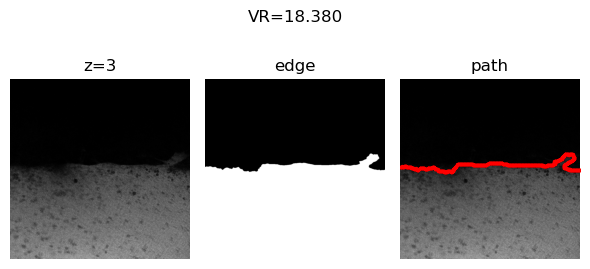

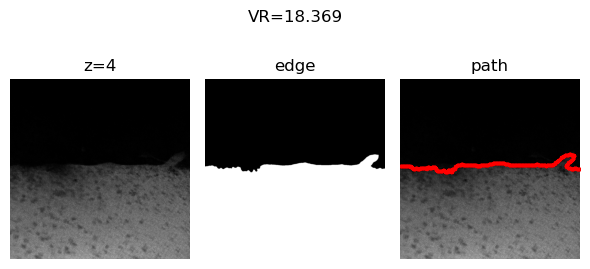

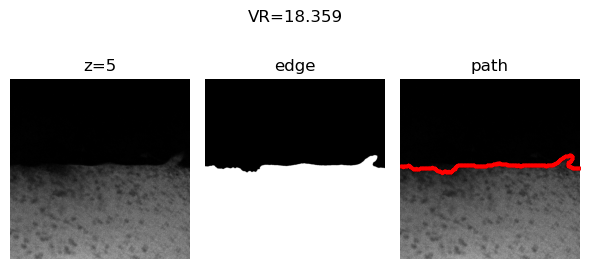

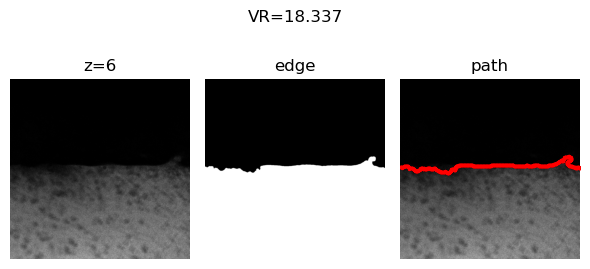

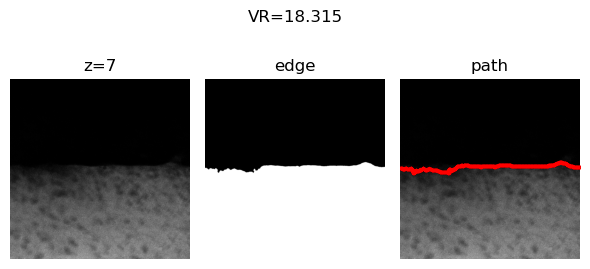

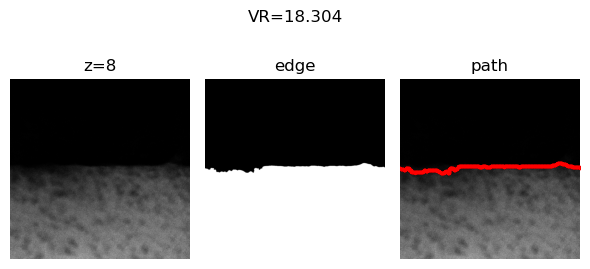

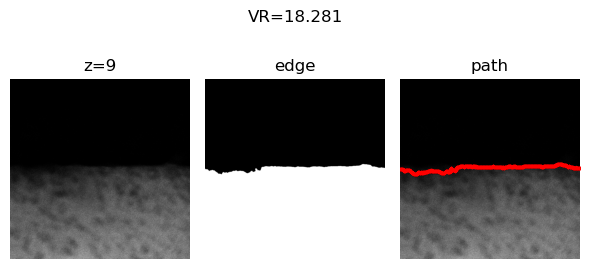

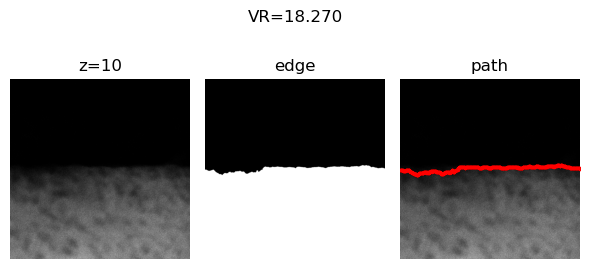

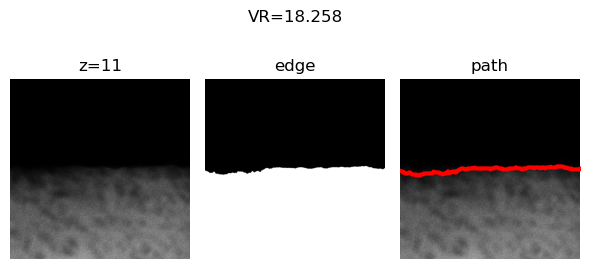

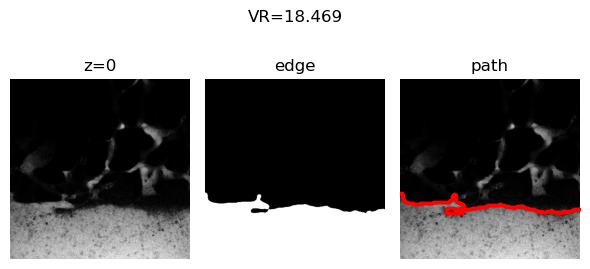

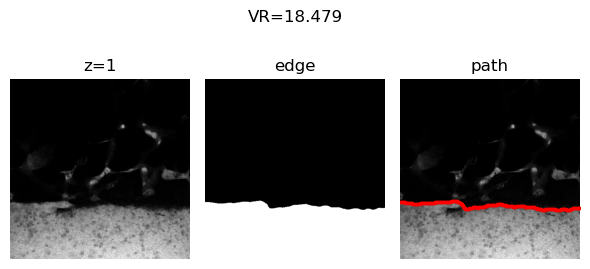

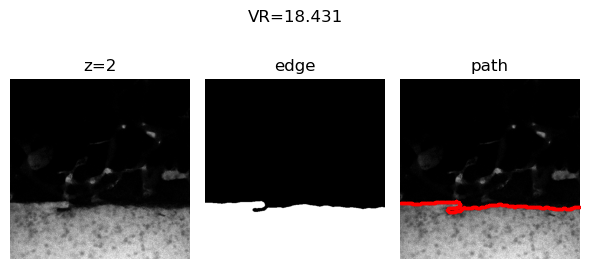

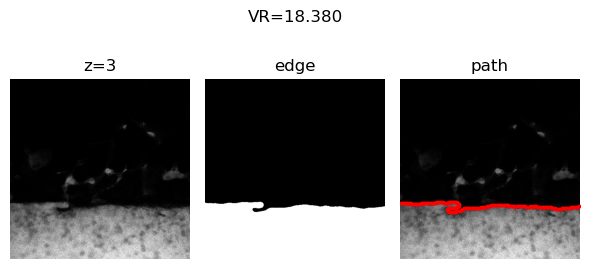

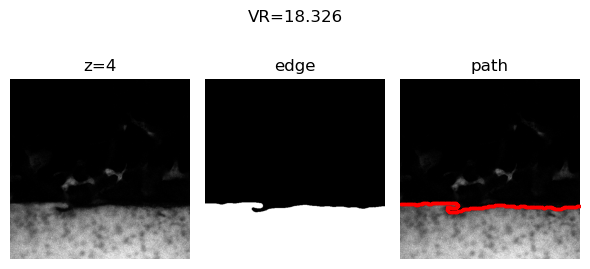

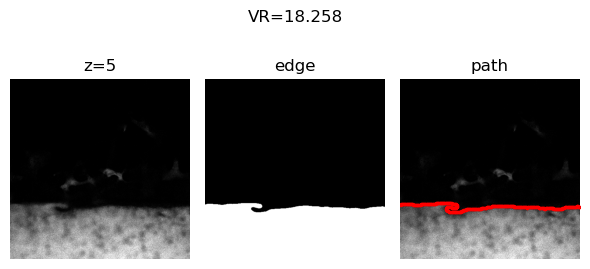

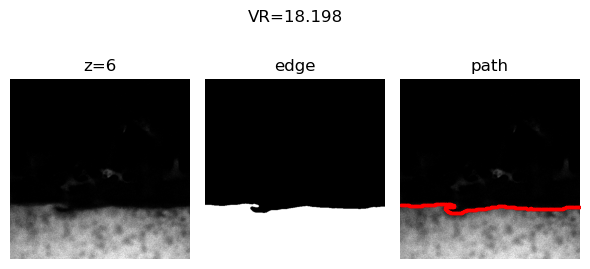

,lif_name,lif_path,image_index,image_name,image_shape,n_planes_found,n_planes_kept,kept_z_min,kept_z_max,maternal_region_volume_px,...,t1_t2_pct_change,t2_t3_pct_change,maternal_um3,fetal_um3,interface_um2,x_um,z_um,failed_geometry,geom_diag,error
0,Exp1_Hormones_Prog_Estr+20251113.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 1,"(4, 3, 14, 512, 512)",2.0,1.0,6.0,6.0,168676.0,...,-6.271692,-36.624947,4.364935e+06,2.418730e+06,8485.769863,2.274951,5.000119,False,NaN,NaN
1,Exp1_Thalidomide_20251113.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 2,"(4, 2, 16, 512, 512)",16.0,4.0,6.0,10.0,816231.0,...,81.943662,-22.195907,4.224222e+07,2.559118e+07,115430.227082,2.274951,9.999760,False,NaN,NaN
2,Exp1_Thalidomide_20251113.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 2,"(4, 2, 16, 512, 512)",16.0,4.0,6.0,10.0,816231.0,...,81.943662,-22.195907,4.224222e+07,2.559118e+07,115430.227082,2.274951,9.999760,False,NaN,NaN
3,Test1_Paclitaxel-treat.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 1,"(4, 2, 12, 1024, 1024)",11.0,10.0,2.0,11.0,5355038.0,...,-33.570247,11.955405,6.915244e+07,6.625572e+07,184993.088636,1.136364,10.000236,False,NaN,NaN
4,Test2_Paclitaxel-treat.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 1,"(4, 2, 7, 512, 512)",7.0,7.0,0.0,6.0,537279.0,...,19.207517,-7.901841,2.780569e+07,6.716110e+07,116960.402425,2.274951,9.999762,False,NaN,NaN
5,Exp2_Valproic-Acid_20251114.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 2,"(4, 3, 23, 512, 512)",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_kept_slices
6,Exp6_20260122_Thalidomide-Ibuprofen.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 1,"(4, 3, 41, 512, 512)",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_kept_slices
7,Exp3_Valproic-Acid_20251219,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 1,"(4, 3, 22, 512, 512)",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_kept_slices
8,Exp1bis_Permeability_No-FetalMV.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 2,"(3, 2, 26, 512, 512)",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,index 3 is out of bounds for axis 0 with size 3
9,Exp5_20260119_Thalidomide-Ibuprofen.lif,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,0,P 2,"(4, 3, 42, 512, 512)",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no_kept_slices


In [83]:

# channel indices
DEXTRAN_CHANNEL = 0

# analysis parameters
params = RidgeParams(
    ratio_cutoff=0.9,
    # optional speed tweak:
    sato_sigmas=(2, 3, 4, 5, 6, 7, 8),
)

results: List[Dict[str, object]] = []
print(len(lif_files))
for lif_path in lif_files:
    with LifFile(lif_path) as lif:
        for image_index, lif_img in enumerate(lif.images):
            if image_index == 0:
                try:
                    xa = lif_img.asxarray()
                    x_um = step("X", xa) * 1e6 if step("X", xa) is not None else None
                    z_um = step("Z", xa) * 1e6 if step("Z", xa) is not None else None

                    img = lif_img.asarray()

                    dextran_t0 = img[0, DEXTRAN_CHANNEL, :, :, :]
                    dextran_t1 = img[1, DEXTRAN_CHANNEL, :, :, :]
                    dextran_t2 = img[2, DEXTRAN_CHANNEL, :, :, :]
                    dextran_t3 = img[3, DEXTRAN_CHANNEL, :, :, :]

                    # 1) detect per-slice lines + profiles
                    lines, profiles, found_zs = collect_lines_over_z(
                        dextran_t0,
                        params=params,
                        plot=True,
                    )

                    # 2) keep consistent z-band
                    kept_zs, kept_lines = keep_similar_high_z(
                        lines,
                        profiles,
                        found_zs,
                        missing_run=3,
                        consec_bad=2,
                        core_frac=0.6,
                        diff_thresh_px=25,
                    )

                    if not kept_zs:
                        results.append(
                            {
                                "lif_name": lif.name,
                                "lif_path": str(lif_path),
                                "image_index": image_index,
                                "image_name": getattr(lif_img, "name", None),
                                "image_shape": getattr(lif_img, "shape", None),
                                "error": "no_kept_slices",
                            }
                        )
                        continue

                    failed, geom_diag = segmentation_geometry_failure(
                        profiles,
                        kept_zs,
                        y_max=dextran_t0.shape[1],  # H
                    )

                    # 3) segment using a smoothed surface (prevents jagged overlap artefacts)
                    (
                        maternal_region,
                        fetal_region,
                        area_by_z,
                        maternal_region_volume,
                        fetal_region_volume,
                        y_smooth_zx,
                        used_zs,
                    ) = segment_from_smoothed_surface(
                        dextran_t0.shape,
                        kept_zs,
                        profiles,
                        side="below",
                        sigma_z=1.0,
                        sigma_x=3.0,
                        fill_within_kept_band=True,
                    )

                    maternal_um3, fetal_um3, interface_um2 = measure_volumes_and_interface_um(
                        maternal_region,
                        fetal_region,
                        x_um=x_um,
                        z_um=z_um,
                    )

                    t0_maternal_intensity = np.float64(np.sum(dextran_t0[maternal_region == 1]))
                    t0_fetal_intensity = np.float64(np.sum(dextran_t0[fetal_region == 1]))

                    t1_maternal_intensity = np.float64(np.sum(dextran_t1[maternal_region == 1]))
                    t1_fetal_intensity = np.float64(np.sum(dextran_t1[fetal_region == 1]))

                    t2_maternal_intensity = np.float64(np.sum(dextran_t2[maternal_region == 1]))
                    t2_fetal_intensity = np.float64(np.sum(dextran_t2[fetal_region == 1]))

                    t3_maternal_intensity = np.float64(np.sum(dextran_t3[maternal_region == 1]))
                    t3_fetal_intensity = np.float64(np.sum(dextran_t3[fetal_region == 1]))

                    bleaching_coefficient_t0_t1 = t0_maternal_intensity / t1_maternal_intensity
                    bleaching_coefficient_t1_t2 = t1_maternal_intensity / t2_maternal_intensity
                    bleaching_coefficient_t2_t3 = t2_maternal_intensity / t3_maternal_intensity
                    bleaching_coefficient_t0_t3 = t0_maternal_intensity / t3_maternal_intensity

                    t0_t3_p = permeability_calculation(
                        t3_fetal_intensity,
                        t0_fetal_intensity,
                        t0_maternal_intensity,
                        180 * 3,
                        bleaching_coefficient_t0_t3,
                        fetal_um3,
                        interface_um2,
                    )
                    t0_t1_p = permeability_calculation(
                        t1_fetal_intensity,
                        t0_fetal_intensity,
                        t0_maternal_intensity,
                        180,
                        bleaching_coefficient_t0_t1,
                        fetal_um3,
                        interface_um2,
                    )
                    t1_t2_p = permeability_calculation(
                        t2_fetal_intensity,
                        t1_fetal_intensity,
                        t1_maternal_intensity,
                        180,
                        bleaching_coefficient_t1_t2,
                        fetal_um3,
                        interface_um2,
                    )
                    t2_t3_p = permeability_calculation(
                        t3_fetal_intensity,
                        t2_fetal_intensity,
                        t2_maternal_intensity,
                        180,
                        bleaching_coefficient_t2_t3,
                        fetal_um3,
                        interface_um2,
                    )

                    results.append(
                        {
                            "lif_name": lif.name,
                            "lif_path": str(lif_path),
                            "image_index": image_index,
                            "image_name": getattr(lif_img, "name", None),
                            "image_shape": getattr(lif_img, "shape", None),
                            "n_planes_found": len(found_zs),
                            "n_planes_kept": len(kept_zs),
                            "kept_z_min": int(kept_zs[0]),
                            "kept_z_max": int(kept_zs[-1]),
                            "maternal_region_volume_px": int(maternal_region_volume),
                            "fetal_region_volume_px": int(fetal_region_volume),
                            "t0_t3_p": float(t0_t3_p),
                            "t0_t1_p": float(t0_t1_p),
                            "t1_t2_p": float(t1_t2_p),
                            "t2_t3_p": float(t2_t3_p),
                            "t0_t1_pct_change": float(100 * (t0_t1_p - t0_t3_p) / t0_t3_p),
                            "t1_t2_pct_change": float(100 * (t1_t2_p - t0_t3_p) / t0_t3_p),
                            "t2_t3_pct_change": float(100 * (t2_t3_p - t0_t3_p) / t0_t3_p),
                            "maternal_um3": float(maternal_um3),
                            "fetal_um3": float(fetal_um3),
                            "interface_um2": float(interface_um2),
                            "x_um": x_um,
                            "z_um": z_um,
                            "failed_geometry": bool(failed),
                            "geom_diag": geom_diag if failed else None,
                        }
                    )

                except Exception as exc:
                    results.append(
                        {
                            "lif_name": lif.name,
                            "lif_path": str(lif_path),
                            "image_index": image_index,
                            "image_name": getattr(lif_img, "name", None),
                            "image_shape": getattr(lif_img, "shape", None),
                            "error": str(exc),
                        }
                    )

results_df = pd.DataFrame(results)
results_df

In [72]:
results_df

""


In [81]:
viewer = napari.Viewer()
viewer.add_image(dextran_t0)
viewer.add_labels(maternal_region , colormap=label_colormap("dodgerblue", alpha=0.2))
viewer.add_labels(fetal_region, colormap={0: np.array([0., 0., 0., 0.]), 1:np.array([1.,0.,0.,0.2])} )


<Labels layer 'fetal_region' at 0x24fbcdf7310>

In [6]:
print(maternal_um3/fetal_um3)

1.005472643868409


In [8]:
test_mean =np.mean([t0_t1_p, t1_t2_p, t2_t3_p])
print(test_mean, t0_t3_p, (test_mean - t0_t3_p) / t0_t3_p *100)

3.0308211427397313e-06 2.970899731368255e-06 2.016944925431038


In [73]:
results_df = pd.read_csv("Placenta_new_permeability_results.csv")

In [74]:
results

[]